# Credit Card Fraud Detection Capstone

## Module 20: Exploratory Data Analysis and Baseline Model

### Research Question
What factors influence whether a credit card transaction is fraudulent, and how accurately can fraud be predicted using transaction data?

### Objective
This notebook performs the core analysis work for the capstone project by:
- loading and inspecting a credit card fraud dataset
- cleaning and preparing the data
- performing exploratory data analysis (EDA)
- engineering useful features
- training a baseline machine learning model
- interpreting early findings for technical and non-technical audiences

### Dataset Assumption
This is designed for **Kaggle Credit Card Fraud Detection** dataset, which typically includes the following columns:
- `Time`
- `Amount`
- `V1` to `V28`
- `Class` where 0 = legitimate transaction and 1 = fraudulent transaction


In [1]:
# Import required libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

## 1. Load the Data


In [20]:
# Lfileoad dataset
file_path = 'creditcard.csv'

try:
    df = pd.read_csv("creditcard.csv")
    print('Dataset loaded successfully.')
except FileNotFoundError:
    print('File not found. Please update `file_path` to the correct dataset location.')
    df = None

Dataset loaded successfully.


In [21]:
if df is not None:
    print('Shape of dataset:', df.shape)
    display(df.head())

Shape of dataset: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Initial Data Inspection

This section checks the data types, missing values, duplicates, and overall structure of the dataset.

In [22]:
if df is not None:
    print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [23]:
if df is not None:
    missing_values = df.isnull().sum().sort_values(ascending=False)
    duplicate_count = df.duplicated().sum()

    print('Missing values by column:')
    display(missing_values[missing_values > 0])
    print('Total duplicate rows:', duplicate_count)

Missing values by column:


Series([], dtype: int64)

Total duplicate rows: 1081


In [24]:
if df is not None and duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print('Duplicates removed. New shape:', df.shape)

Duplicates removed. New shape: (283726, 31)


## 3. Basic Data Cleaning

For this dataset, common cleaning tasks include:
- checking that the target variable exists
- confirming numeric data types
- making sure there are no invalid labels in the target variable

In [25]:
if df is not None:
    print('Columns:', list(df.columns))

    if 'Class' in df.columns:
        print('Target distribution:')
        print(df['Class'].value_counts())
    else:
        print("Target column 'Class' not found. Please adjust the notebook for your dataset.")

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Target distribution:
Class
0    283253
1       473
Name: count, dtype: int64


## 4. Feature Engineering

To make the analysis more interpretable, a few simple features are created from the original data.

### Planned engineered features
- `Hour`: approximate hour of the transaction based on the `Time` column
- `Log_Amount`: log-transformed transaction amount to reduce skewness
- `Amount_Bin`: grouped transaction amount ranges for easier visualization

In [28]:
if df is not None:
    if 'Time' in df.columns:
        df['Hour'] = (df['Time'] // 3600) % 24

    if 'Amount' in df.columns:
        df['Log_Amount'] = np.log1p(df['Amount'])
        df['Amount_Bin'] = pd.qcut(df['Amount'], q=4, duplicates='drop', labels=['Low', 'Medium', 'High', 'Very High'])

    display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Class,Hour,Log_Amount,Amount_Bin
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0,5.014760,Very High
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0,1.305626,Low
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0,5.939276,Very High
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0,4.824306,Very High
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0,4.262539,High


## 5. Exploratory Data Analysis (EDA)

EDA is used here to understand class imbalance, transaction behavior, and how fraudulent transactions differ from legitimate transactions.

### 5.1 Class Distribution

Fraud detection datasets are usually highly imbalanced. This is important because high accuracy alone can be misleading.

Class counts:
Class
0    283253
1       473
Name: count, dtype: int64
Class percentages:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


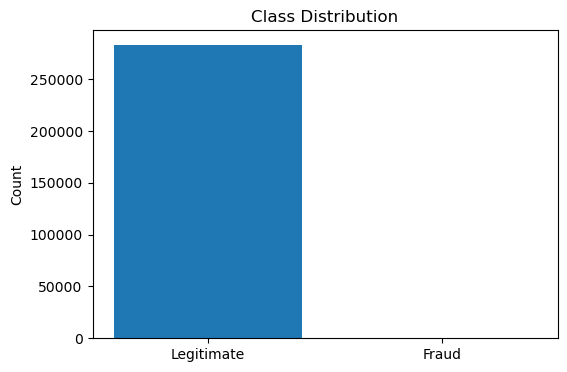

In [29]:
if df is not None and 'Class' in df.columns:
    class_counts = df['Class'].value_counts().sort_index()
    class_percentages = df['Class'].value_counts(normalize=True).sort_index() * 100

    print('Class counts:')
    print(class_counts)
    print('Class percentages:')
    print(class_percentages)

    plt.figure(figsize=(6,4))
    plt.bar(['Legitimate', 'Fraud'], class_counts.values)
    plt.title('Class Distribution')
    plt.ylabel('Count')
    plt.show()

### 5.2 Transaction Amount Distribution

This section examines whether fraudulent transactions differ from legitimate transactions in terms of amount.

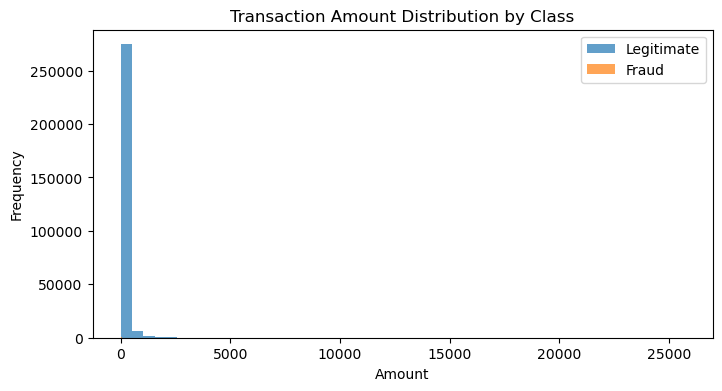

In [30]:
if df is not None and {'Amount', 'Class'}.issubset(df.columns):
    plt.figure(figsize=(8,4))
    plt.hist(df[df['Class'] == 0]['Amount'], bins=50, alpha=0.7, label='Legitimate')
    plt.hist(df[df['Class'] == 1]['Amount'], bins=50, alpha=0.7, label='Fraud')
    plt.title('Transaction Amount Distribution by Class')
    plt.xlabel('Amount')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

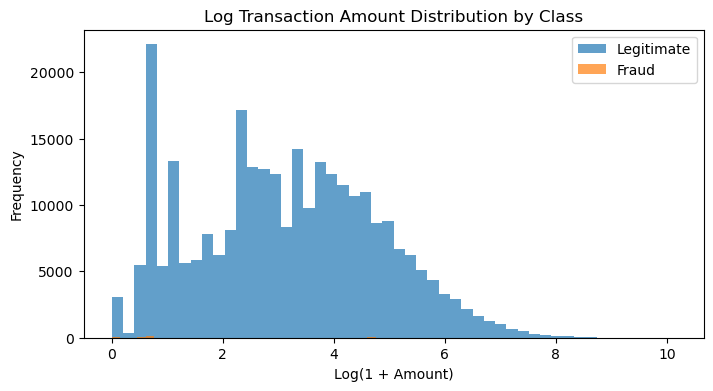

In [12]:
if df is not None and {'Log_Amount', 'Class'}.issubset(df.columns):
    plt.figure(figsize=(8,4))
    plt.hist(df[df['Class'] == 0]['Log_Amount'], bins=50, alpha=0.7, label='Legitimate')
    plt.hist(df[df['Class'] == 1]['Log_Amount'], bins=50, alpha=0.7, label='Fraud')
    plt.title('Log Transaction Amount Distribution by Class')
    plt.xlabel('Log(1 + Amount)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

### 5.3 Transaction Time Patterns

This section explores whether fraudulent transactions are concentrated at certain times.

,Legitimate,Fraud
Hour,,
0.0,7641,6
1.0,4198,10
2.0,3260,48
3.0,3470,17
4.0,2181,23


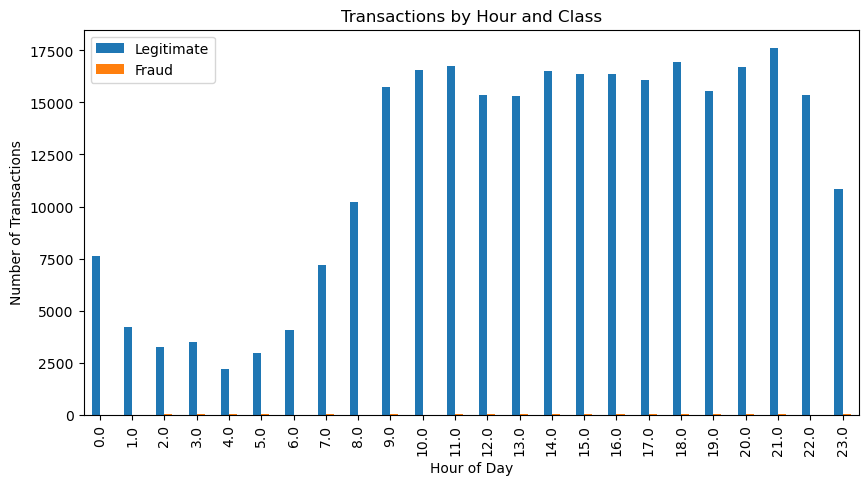

In [31]:
if df is not None and {'Hour', 'Class'}.issubset(df.columns):
    hourly_counts = df.groupby(['Hour', 'Class']).size().unstack(fill_value=0)
    hourly_counts.columns = ['Legitimate', 'Fraud']
    display(hourly_counts.head())

    hourly_counts.plot(kind='bar', figsize=(10,5))
    plt.title('Transactions by Hour and Class')
    plt.xlabel('Hour of Day')
    plt.ylabel('Number of Transactions')
    plt.show()

### 5.4 Correlation Analysis

A correlation heatmap helps identify relationships among numeric variables. If the dataset contains many transformed variables such as `V1` to `V28`, the heatmap can also show which features appear most associated with fraud.

In [32]:
if df is not None and 'Class' in df.columns:
    corr = df.select_dtypes(include=np.number).corr()

    top_corr = corr['Class'].sort_values(ascending=False)
    print('Top positive correlations with fraud:')
    print(top_corr.head(10))
    print('Top negative correlations with fraud:')
    print(top_corr.tail(10))

Top positive correlations with fraud:
Class    1.000000
V11      0.149067
V4       0.129326
V2       0.084624
V19      0.033631
V8       0.033068
V21      0.026357
V27      0.021892
V20      0.021486
V28      0.009682
Name: Class, dtype: float64
Top negative correlations with fraud:
V9    -0.094021
V1    -0.094486
V18   -0.105340
V7    -0.172347
V3    -0.182322
V16   -0.187186
V10   -0.206971
V12   -0.250711
V14   -0.293375
V17   -0.313498
Name: Class, dtype: float64


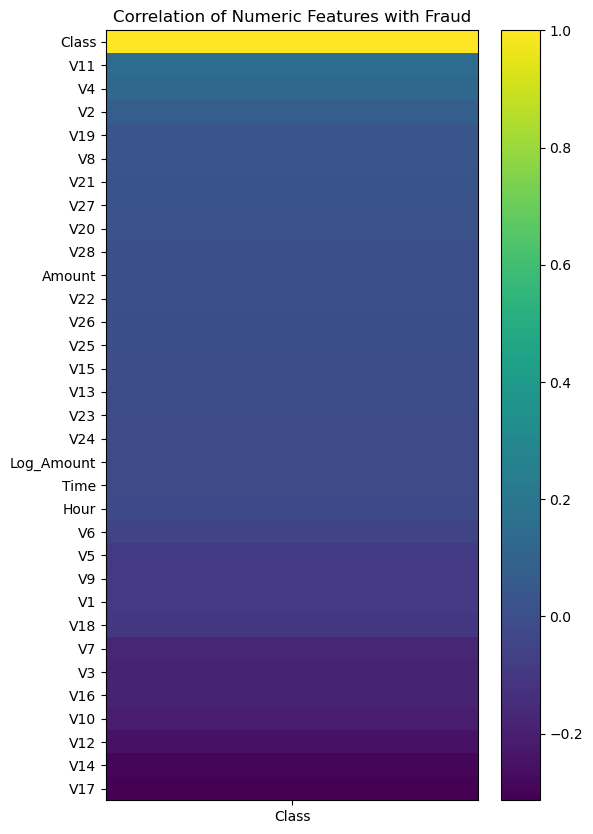

In [16]:
if df is not None and 'Class' in df.columns:
    corr_with_class = df.select_dtypes(include=np.number).corr()[['Class']].sort_values(by='Class', ascending=False)

    plt.figure(figsize=(6,10))
    plt.imshow(corr_with_class, aspect='auto')
    plt.yticks(range(len(corr_with_class.index)), corr_with_class.index)
    plt.xticks([0], ['Class'])
    plt.title('Correlation of Numeric Features with Fraud')
    plt.colorbar()
    plt.show()

### 5.5 Summary of Early EDA Findings

The exploratory analysis shows that fraud is extremely rare in this dataset. After removing duplicate records, only **473** of **283,726** transactions were labeled as fraud, which is about **0.17%** of the data. This confirms that the project is dealing with a highly imbalanced classification problem, so accuracy alone will not be enough to judge model quality.

The amount-based plots suggest that transaction value has some relationship with fraud, but it is not a complete explanation by itself. The log-transformed amount view makes the comparison easier and shows that fraudulent activity is spread across different transaction sizes rather than being limited to only the largest purchases.

The time-based analysis indicates that fraud is not evenly distributed across the day. Some hours show noticeably higher fraud counts than others, which suggests that transaction timing may provide useful signal when combined with other variables.

The correlation output also shows that no single variable perfectly explains fraud. Instead, the strongest signals come from a combination of transformed features, especially variables such as **V14, V17, V12, V10, V16, V3, V7**, and on the positive side **V11, V4, and V2**. This supports the idea that fraud detection will likely depend on patterns across multiple features rather than one simple rule.

## 6. Baseline Model: Logistic Regression

A baseline model is needed in this module so that improved models can be compared in Module 24. Logistic regression is a good starting point because it is simple and interpretable.

In [33]:
if df is not None and 'Class' in df.columns:
    # Select numeric features and exclude the target
    feature_columns = [col for col in df.select_dtypes(include=np.number).columns if col != 'Class']
    X = df[feature_columns]
    y = df['Class']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    print('Classification Report:')
    print(classification_report(y_test, y_pred))

    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))

    print('ROC-AUC Score:', roc_auc_score(y_test, y_prob))
    print('Average Precision Score:', average_precision_score(y_test, y_prob))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.97      0.99     56746

Confusion Matrix:
[[55239  1412]
 [   12    83]]
ROC-AUC Score: 0.9682017040624544
Average Precision Score: 0.6708487390779021


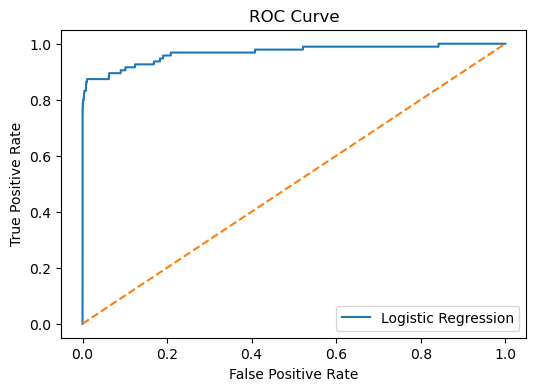

In [35]:
if df is not None and 'Class' in df.columns:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label='Logistic Regression')
    plt.plot([0,1], [0,1], linestyle='--')
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()

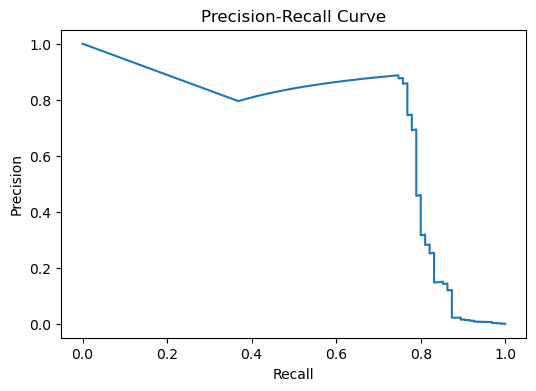

In [34]:
if df is not None and 'Class' in df.columns:
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.figure(figsize=(6,4))
    plt.plot(recall, precision)
    plt.title('Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.show()

## 7. Baseline Model Interpretation

The baseline logistic regression model produced mixed but useful results. It achieved a **recall of 0.87** for fraudulent transactions, which means it correctly identified **83 out of 95** fraud cases in the test set. This is encouraging because, in a fraud detection problem, missing fraudulent activity is usually more costly than incorrectly flagging a normal transaction.

At the same time, the model’s **precision for fraud was only 0.06**. In practice, this means that many transactions flagged as suspicious were actually legitimate. The confusion matrix shows this clearly: the model generated **1,412 false positives** while only missing **12 fraud cases**. So the model is aggressive in catching fraud, but it does so at the cost of flagging many normal transactions.

The overall **accuracy of 0.97** looks high, but this should be interpreted carefully because the dataset is heavily imbalanced. More informative metrics here are the **ROC-AUC score of 0.968** and the **average precision score of 0.671**, which show that the model does capture meaningful separation between fraudulent and legitimate behavior.

Overall, this baseline model is a reasonable starting point. It demonstrates that the available features contain strong predictive signal, but it also shows that additional work is needed to improve precision and reduce the number of false alarms.


## 8. Key Findings So Far

Based on the EDA and baseline model, the main findings at this stage are:

1. Fraud is extremely rare in the dataset, making class imbalance one of the central challenges of the project.
2. Duplicate records were present in the raw data and needed to be removed before analysis.
3. Transaction amount and transaction time both appear to contain useful information, but neither one is enough on its own to explain fraudulent behavior.
4. The strongest signals appear to come from a combination of transformed variables, especially features such as V14, V17, V12, V10, V16, V11, V4, and V2.
5. The baseline logistic regression model was effective at finding most fraud cases, but it produced many false positives, showing that there is a tradeoff between catching fraud and over-flagging legitimate transactions.
6. The baseline results provide a solid benchmark for comparing stronger models in the next stage of the project.

## 9. Next Steps

The next phase of the project will focus on improving performance beyond this baseline. Planned next steps include:

- testing additional models such as decision trees, random forests, or other ensemble methods
- tuning model settings to improve the balance between recall and precision
- exploring class imbalance strategies such as resampling or class weighting
- refining feature engineering to capture stronger behavioral patterns
- comparing models using fraud-sensitive metrics such as recall, precision, F1-score, ROC-AUC, and average precision
- improving the final presentation so the findings are clear for both technical and non-technical audiences

These steps will help determine whether more advanced methods can reduce false positives while still keeping fraud detection strong.

## 10. Conclusion

This notebook completed the main analytical work for the module by combining data inspection, cleaning, feature engineering, exploratory analysis, visualization, and a baseline machine learning model. The results show that fraudulent transactions are rare and that fraud detection in this dataset depends on subtle relationships across multiple variables rather than one obvious indicator.

The baseline logistic regression model showed that the dataset contains meaningful predictive signal. It was able to identify most fraudulent transactions, but it also flagged many legitimate transactions incorrectly. This confirms that the project is moving in the right direction, while also showing that model refinement is necessary before the results can be considered practical for real-world fraud screening.

Overall, the work in this notebook provides an initial answer to the research question and creates a clear benchmark for the next module, where more advanced models and improved methods can be evaluated.